In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

# 1️⃣ Load your dataset
df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

text_col = "catalog_content"
df[text_col] = df[text_col].fillna("").astype(str)
test_df[text_col] = test_df[text_col].fillna("").astype(str)


In [2]:
# 2️⃣ Create simple numeric text features
def make_features(s):
    s = s.fillna("").astype(str)
    return np.vstack([
        s.str.len().values,          # text length
        s.str.split().map(len).values,  # word count
        s.str.count(r"\d").values,   # number of digits
        s.str.count(",").values,     # commas
        s.str.count("\.").values     # periods
    ]).T

X_train_features = make_features(df[text_col])
X_test_features = make_features(test_df[text_col])

# Add sample_id as numeric
X_train_features = np.hstack([X_train_features, df["sample_id"].values.reshape(-1, 1)])
X_test_features = np.hstack([X_test_features, test_df["sample_id"].values.reshape(-1, 1)])

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

print("Feature matrix shape:", X_train_scaled.shape)


<>:9: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:9: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
/var/folders/hg/6k2xrn0x1hxd4zlz_g32w19h0000gn/T/ipykernel_12109/3275434702.py:9: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  s.str.count("\.").values     # periods


Feature matrix shape: (75000, 6)


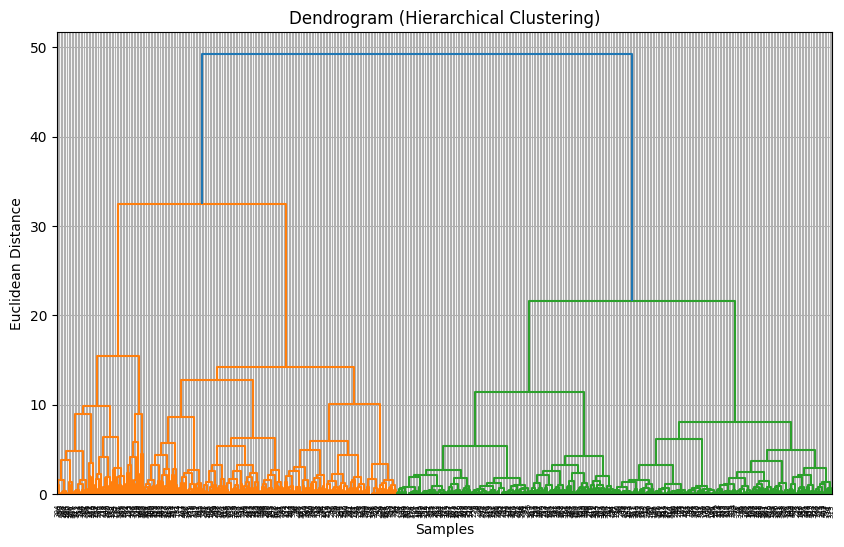

: 

In [ ]:
# 3️⃣ Dendrogram to find suitable number of clusters
plt.figure(figsize=(10, 6))
linked = sch.linkage(X_train_scaled[:500], method='ward')  # use subset if data large
sch.dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title("Dendrogram (Hierarchical Clustering)")
plt.xlabel("Samples")
plt.ylabel("Euclidean Distance")
plt.grid(True)
plt.show()


In [ ]:
# 4️⃣ Train Hierarchical Clustering model
BEST_K = 4   # 👈 choose based on dendrogram
agg = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
df["cluster"] = agg.fit_predict(X_train_scaled)

# Predict cluster labels for test data
# (Agglomerative doesn't have predict, so assign nearest)
from sklearn.neighbors import NearestCentroid
centroids = NearestCentroid()
centroids.fit(X_train_scaled, df["cluster"])
test_clusters = centroids.predict(X_test_scaled)
test_df["cluster"] = test_clusters

print("✅ Assigned", BEST_K, "clusters.")
df.head()


In [ ]:
# 5️⃣ Reduce dimensions to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=df["cluster"], cmap='tab10', s=15)
plt.title(f"Hierarchical Clustering Visualization (k={BEST_K})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()


In [ ]:
# 6️⃣ Save clustered data
df.to_csv("train_hierarchical_clusters.csv", index=False)
test_df.to_csv("test_hierarchical_clusters.csv", index=False)
print("💾 Saved 'train_hierarchical_clusters.csv' and 'test_hierarchical_clusters.csv'")
